In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
!pip install transformers==4.55.4

!pip install gluonnlp pandas tqdm
!pip install mxnet
!pip install sentencepiece

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
import re
import os
import urllib.request
from tqdm import tqdm
from transformers import BertTokenizer, TFBertForSequenceClassification

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/캡스톤디자인/뉴스 감성분석/학습 데이터/학습데이터_label.csv")
data.head()

,keyword,month,title,url,summary,label
0,원유,05-Jan,(뉴욕/개장전)선물 상승..M&A 봇물,https://n.news.naver.com/mnews/article/018/000...,보험 브로커 회사인 마쉬 앤 멕레난는 보험 입찰 담합과 관련 엘리어트 스피처 뉴욕검...,1
1,원유,05-Jan,인천정유 매각 원점…채권단，中시노켐 6851억원 제시 거부,https://n.news.naver.com/mnews/article/014/000...,시노켐 관계자는 시노켐이 인천정유를 선택한 것은 원유정제시설 확보 중국 와 성장 인...,2
2,원유,05-Jan,[증시 올 3대 외부변수－국제 유가]50弗 밑돌아야 악재 면해,https://n.news.naver.com/mnews/article/014/000...,그렇지만 석유수출기구 OPEC 가 유가급락에 대한 감산가능성을 여전히 남겨놓고 있어...,0
3,원유,05-Jan,미 기업 ‘리비아 석유채굴권’ 독식,https://n.news.naver.com/mnews/article/028/000...,리비아는 테러 지원 의혹과 팬암기 폭파사건 등으로 80년대 후반 미국과 유엔으로부터...,1
4,원유,05-Jan,"베네수엘라, 중국과원유개발 합의",https://n.news.naver.com/mnews/article/028/000...,이란 도움 받으며 아시아로 수출 세계 5위의 석유수출국인 베네수엘라가 수출시장을 기...,1


In [ ]:
del data['keyword']
del data['month']
del data['title']
del data['url']

In [ ]:
duplicate = data[data.duplicated()]

In [ ]:
# 중복 제거
data.drop_duplicates(subset=['summary'], inplace=True)
print('총 샘플의 수 :',len(data))

총 샘플의 수 : 77602


<Axes: xlabel='label'>

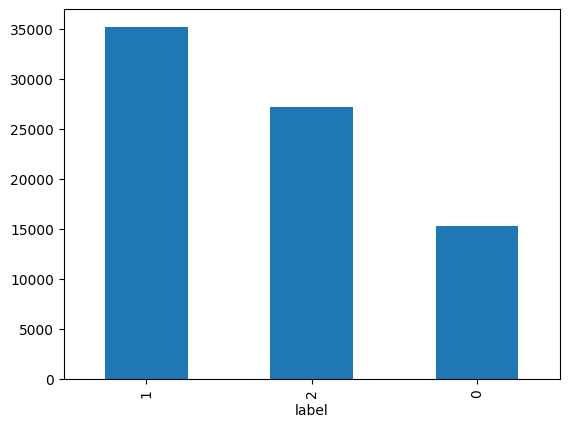

In [ ]:
data['label'].value_counts().plot(kind='bar')

In [ ]:
X_data = data['summary']
y_data = data['label']
print('본문의 개수: {}'.format(len(X_data)))
print('레이블의 개수: {}'.format(len(y_data)))

본문의 개수: 77602
레이블의 개수: 77602


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=0, stratify=y_data)

In [ ]:
max_seq_len = 128

In [ ]:
tokenizer = BertTokenizer.from_pretrained('klue/bert-base')

In [ ]:
def convert_examples_to_features(examples, labels, max_seq_len, tokenizer):

    input_ids, attention_masks, token_type_ids, data_labels = [], [], [], []

    for example, label in tqdm(zip(examples, labels), total=len(examples)):
        input_id = tokenizer.encode_plus(
            example,
            add_special_tokens=True,
            max_length=max_seq_len,
            padding='max_length',
            truncation=True
        )["input_ids"]

        padding_count = input_id.count(tokenizer.pad_token_id)
        attention_mask = [1] * (max_seq_len - padding_count) + [0] * padding_count

        token_type_id = [0] * max_seq_len

        assert len(input_id) == max_seq_len, "Error with input length {} vs {}".format(len(input_id), max_seq_len)
        assert len(attention_mask) == max_seq_len, "Error with attention mask length {} vs {}".format(len(attention_mask), max_seq_len)
        assert len(token_type_id) == max_seq_len, "Error with token type length {} vs {}".format(len(token_type_id), max_seq_len)

        input_ids.append(input_id)
        attention_masks.append(attention_mask)
        token_type_ids.append(token_type_id)
        data_labels.append(label)

    input_ids = np.array(input_ids, dtype=int)
    attention_masks = np.array(attention_masks, dtype=int)
    token_type_ids = np.array(token_type_ids, dtype=int)

    data_labels = np.asarray(data_labels, dtype=np.int32)

    return (input_ids, attention_masks, token_type_ids), data_labels

In [ ]:
train_X, train_y = convert_examples_to_features(X_train, y_train, max_seq_len=max_seq_len, tokenizer=tokenizer)

100%|██████████| 62081/62081 [00:33<00:00, 1872.95it/s]


In [ ]:
test_X, test_y = convert_examples_to_features(X_test, y_test, max_seq_len=max_seq_len, tokenizer=tokenizer)

100%|██████████| 15521/15521 [00:05<00:00, 2965.21it/s]


In [ ]:
input_id = train_X[0][0]
attention_mask = train_X[1][0]
token_type_id = train_X[2][0]
label = train_y[0]

print('단어에 대한 정수 인코딩 :',input_id)
print('어텐션 마스크 :',attention_mask)
print('세그먼트 인코딩 :',token_type_id)
print('각 인코딩의 길이 :', len(input_id))
print('정수 인코딩 복원 :',tokenizer.decode(input_id))
print('레이블 :',label)

단어에 대한 정수 인코딩 : [    2  4661  3989 31302  4661  3989 31302  1460  3659  2079  4461  3773
  2073  4744   904  2138 19478  2299  4272  4338  3719  2170  2259  1460
  4744 14102 20244  3621  1041  2052 20500  2069  3681  2200  4272  2614
  7645  2052 27308  2689  2259  9575  3659  2259  4461  3648  2069  4262
  2267  2067  2089 18395  2259  4659  2116  1513  2015  2259  1891  9575
  1039  2073  3611  2031  2079 11525 28674    18  3744  2170  2259    21
  2337  7556  2082  2446  1478  2299  2118  6355 29385  2327  2138  4952
  2200  3659  2116  4461  3648  2170  1311  2318  5671 31302  4390  4000
  3758  2119  3853  2088  1513  2062    18     3     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0]
어텐션 마스크 : [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1

In [ ]:
strategy = tf.distribute.get_strategy()

In [ ]:
import tensorflow as tf
from transformers import TFBertForSequenceClassification
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
import tf_keras as keras
from tf_keras.optimizers import Adam

model = TFBertForSequenceClassification.from_pretrained("klue/bert-base", num_labels=3, from_pt=True)

optimizer = Adam(learning_rate=5e-5)
loss_fn = SparseCategoricalCrossentropy(from_logits=True)

model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertForSequenceClassification: ['bert.embeddings.position_ids']
- This IS expected if you are initializing TFBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should p

In [ ]:
import tf_keras as keras
from tf_keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=2)

model.fit(
    train_X, train_y,
    epochs=2,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/2
1552/1552 [==============================] - 1438s 874ms/step - loss: 0.2329 - accuracy: 0.9173 - val_loss: 0.1332 - val_accuracy: 0.9587
Epoch 2/2
1552/1552 [==============================] - 1354s 873ms/step - loss: 0.1195 - accuracy: 0.9610 - val_loss: 0.1362 - val_accuracy: 0.9588


In [ ]:
early_stopping = EarlyStopping(
    monitor="val_accuracy",
    min_delta=0.001,
    patience=2)

model.fit(
    train_X, train_y, epochs=3, batch_size=32, validation_split=0.2,
    callbacks = [early_stopping]
)

In [ ]:
import tf_keras as keras
from tf_keras.optimizers import Adam
from tf_keras.losses import SparseCategoricalCrossentropy

optimizer = Adam(learning_rate=5e-5)
loss_fn = SparseCategoricalCrossentropy(from_logits=True)

model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])

In [ ]:
model.evaluate(test_X, test_y, batch_size=1024)

16/16 [==============================] - 143s 8s/step - loss: 0.1158 - accuracy: 0.9677


[0.1157631054520607, 0.967721164226532]

In [ ]:
# model.save('/content/drive/MyDrive/backup_model', save_format='tf')
# tokenizer.save_pretrained('/content/drive/MyDrive/backup_model_tokenizer')

('/content/drive/MyDrive/backup_model_tokenizer/tokenizer_config.json',
 '/content/drive/MyDrive/backup_model_tokenizer/special_tokens_map.json',
 '/content/drive/MyDrive/backup_model_tokenizer/vocab.txt',
 '/content/drive/MyDrive/backup_model_tokenizer/added_tokens.json')

In [ ]:
from transformers import TFBertForSequenceClassification, AutoTokenizer

model.save_pretrained('/content/drive/MyDrive/캡스톤디자인/뉴스 감성분석/감성분석_모델/model')
tokenizer.save_pretrained('/content/drive/MyDrive/캡스톤디자인/뉴스 감성분석/감성분석_모델/model')

('/content/drive/MyDrive/캡스톤디자인/뉴스 감성분석/감성분석_모델/model/tokenizer_config.json',
 '/content/drive/MyDrive/캡스톤디자인/뉴스 감성분석/감성분석_모델/model/special_tokens_map.json',
 '/content/drive/MyDrive/캡스톤디자인/뉴스 감성분석/감성분석_모델/model/vocab.txt',
 '/content/drive/MyDrive/캡스톤디자인/뉴스 감성분석/감성분석_모델/model/added_tokens.json')

In [ ]:
from transformers import TFBertForSequenceClassification, AutoTokenizer


model = TFBertForSequenceClassification.from_pretrained('/content/drive/MyDrive/캡스톤디자인/뉴스 감성분석/감성분석_모델/model')
tokenizer = AutoTokenizer.from_pretrained('/content/drive/MyDrive/캡스톤디자인/뉴스 감성분석/감성분석_모델/model')

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All model checkpoint layers were used when initializing TFBertForSequenceClassification.

All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at /content/drive/MyDrive/캡스톤디자인/뉴스 감성분석/감성분석_모델/model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for predictions without further training.


In [ ]:
from sklearn.metrics import classification_report, f1_score

# test_X를 이용한 예측
predictions = model.predict(test_X).logits
predicted_labels = np.argmax(predictions, axis=1)

NameError: name 'test_X' is not defined

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(test_y, predicted_labels, digits=4))

              precision    recall  f1-score   support

           0     0.8195    0.7078    0.7596       154
           1     0.8210    0.8473    0.8339       406
           2     0.8320    0.8589    0.8452       248

    accuracy                         0.8243       808
   macro avg     0.8242    0.8047    0.8129       808
weighted avg     0.8241    0.8243    0.8232       808



In [ ]:
import pandas as pd
import tensorflow as tf
from transformers import AutoTokenizer

df = pd.read_csv("/content/drive/MyDrive/캡스톤디자인/뉴스 감성분석/학습 데이터/기준금리.csv")
texts = df["summary"]

labels = ["0", "1", "2"]

predictions = []
for text in texts:
    inputs = tokenizer(
        text,
        return_tensors="tf",
        truncation=True,
        padding=True,
        max_length=512
    )
    outputs = model(**inputs)
    pred_id = int(tf.argmax(outputs.logits, axis=1).numpy()[0])
    predictions.append(labels[pred_id])

df["label"] = predictions
df.to_excel("/content/drive/MyDrive/test.xlsx", index=False)

분석 완료! news_with_sentiment.xlsx 파일에 결과가 저장되었습니다.
